<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Atom_Beam_Lithography_Sim_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# GPU Monte Carlo atom-beam and matter-wave lithography

This notebook predicts an illustrative ThinkPad-style exposure pattern through a thin transmission mask, comparing a geometric beam model with coherent Fresnel propagation followed by incoherent source averaging. Run the installation cell in Google Colab with a CUDA GPU selected, then run the simulation cell. CuPy accelerates FFT propagation, Gaussian convolution, Poisson sampling, and response calculations; the same implementation runs with NumPy when no GPU is available. The embedded preview was computed on a CPU, and does not certify GPU execution.

The supplied wordmark is a **typographic surrogate**, not the official ThinkPad artwork. The i-dot is part of the same exposure mask; its red brand color is not a physical dose variable. Set `MASK_IMAGE_PATH` to an uploaded grayscale transmission image for a specific design. White transmits, black blocks, and grayscale specifies fractional **intensity** transmission. Transparent PNGs should first be flattened onto a black background. The imported design is scaled to fit the stated field, so its physical size is controlled by `FIELD_WIDTH_UM`.

## Primer and physical scope

A neutral-atom beam is also a matter wave. The two branches below are approximations for the same beam, not unrelated lithography technologies. The geometric limit propagates the transmitted fluence without diffraction; the wave branch retains coherent diffraction within each incident mode. Different incident velocities and angles are treated as mutually incoherent source modes. This is a forward model of a supplied mask, not inverse hologram design or a standing-wave optical-force lens.

| Stage | Direct physical effect | Implementation and limitation |
|---|---|---|
| Thin mask | Modulates transmitted amplitude | Amplitude is the square root of intensity transmission; no membrane thickness or atom-wall forces |
| Longitudinal speed | Sets de Broglie wavelength | Independent lognormal velocity draws, parameterized by arithmetic mean and relative standard deviation |
| Free propagation | Produces Fresnel diffraction | Padded FFT transfer function; periodic computational boundary must remain distant |
| Angular divergence | Shifts each coherent diffraction pattern | Exact Gaussian intensity convolution for independent Gaussian paraxial angles |
| Atom arrivals | Produce shot noise | Independent Poisson counts with mean equal to local fluence times pixel area |
| Surface response spread | Redistributes deposited excitation locally | Assumed Gaussian kernel applied after atom arrivals, distinct from beam divergence |
| Material damage | Converts exposure into an illustrative patterned region | Assumed Hill response followed by a threshold; no calibrated development or etch kinetics |

For mass $m$ and longitudinal velocity $v$, the de Broglie wavelength is

$$\lambda(v)=\frac{h}{mv}.$$

For a normally incident plane-wave mode and intensity transmission $T(x,y)$, the propagated field at mask-substrate gap $z$ is

$$\psi_v(x,y;z)=\mathcal F^{-1}\!\left[\mathcal F\{\sqrt{T}\}\exp\{-i\pi\lambda(v)z(f_x^2+f_y^2)\}\right].$$

Here $f_x,f_y$ are spatial frequencies in cycles per metre. A small incident angle translates the propagated intensity by $z\boldsymbol\theta$. Gaussian angle averaging therefore directly gives a Gaussian convolution with width $\sigma_b=z\sigma_\theta$. The Monte Carlo velocity average is

$$\bar I=\frac{1}{M}\sum_{j=1}^{M}G_{\sigma_b}*|\psi_{v_j}|^2.$$

The geometric counterpart is $I_g=G_{\sigma_b}*T$. Both branches retain absolute transmission throughput and use the same unmasked incident fluence $D_0$. With background fraction $b$ and pixel area $A$, physical arrival counts obey

$$N_{ij}\sim\mathrm{Poisson}\!\left[D_0(\bar I_{ij}+b)A\right].$$

The response dose is $D=G_{\sigma_s}*(N/A)$, where $\sigma_s$ is an assumed surface-response spreading width. The illustrative damage fraction is

$$R(D)=\frac{(D/D_{50})^\gamma}{1+(D/D_{50})^\gamma}.$$

A pixel belongs to the predicted exposed region when $R(D)\ge R_{\mathrm{threshold}}$. Whether that region becomes removed resist, retained material, or an etched opening depends on the actual fabrication process. This is metastable-helium **resist exposure**, not a prediction of helium film deposition.

## Default physical scenario

| Control | Default | Meaning |
|---|---:|---|
| Field width | 12 µm | Full computational region shown, with wordmark fitted inside |
| Grid | 1024 × 384 | Square pixels, approximately 11.7 nm across |
| Atomic mass | 4.002602 u | Helium-4 illustrative beam |
| Mean speed | 1000 m/s | Approximately 99.7 pm de Broglie wavelength |
| Relative speed spread | 8% | Assumed longitudinal source distribution |
| Mask-substrate gap | 50 µm | Approximately 71 nm Fresnel length $\sqrt{\lambda z}$ |
| Angular spread | 0.30 mrad per axis | Approximately 15 nm geometric blur |
| Incident fluence | 30 atoms/nm² | $3\times10^{15}$ atoms/cm² |
| Surface-response spread | 8 nm | Assumed, not measured for a specified resist |
| Damage midpoint | 17 atoms/nm² | Illustrative parameter only |
| Hill exponent | 6 | Assumed dose-response steepness |
| Velocity draws | 48 | Independent integration samples |
| Exposure replicates | 24 | Physical shot-noise repeatability samples |

NIST reports substantial damage near $1.7(3)\times10^{15}$ atoms/cm² for metastable helium in a particular self-assembled-monolayer resist experiment [2]. This equals $17\pm3$ atoms/nm², but **a substantial-damage threshold is not a measured 50% damage midpoint**. The default midpoint merely borrows that order of magnitude; its mapping to the Hill curve is an explicit modeling assumption. Replace it and the response exponent with measured dose-response data before interpreting the result as a process prediction.

Independent sampling is preferable to Metropolis here because the source distribution and arrival law are directly sampleable. A Metropolis or simulated-annealing extension would be useful for inverse mask design, where an acceptance objective trades image error against fabrication constraints; it is not needed for this forward calculation.

In [1]:
"""Install the simulation and CUDA component dependencies."""
import sys
from importlib import metadata

# - Environment compatibility -
conflicting = []
for package in ("cupy", "cupy-cuda11x", "cupy-cuda13x"):
    try:
        metadata.version(package)
    except metadata.PackageNotFoundError:
        continue
    conflicting.append(package)
if conflicting:
    raise RuntimeError(
        "Start a fresh GPU environment before installing cupy-cuda12x. "
        f"Other CuPy distributions detected: {conflicting}"
    )

!{sys.executable} -m pip -q install uv
!uv pip install --python {sys.executable} numpy matplotlib pillow
!uv pip install --python {sys.executable} --upgrade "cupy-cuda12x[ctk]>=14,<15"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 49.8 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Checked 3 packages in 279ms
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 458ms
Prepared 12 packages in 30.58s
Uninstalled 12 packages in 182ms
Installed 12 packages in 58ms
 - cuda-pathfinder==1.8.0
 + cuda-pathfinder==1.8.2
 - cuda-toolkit==12.8.1
 + cuda-toolkit==12.9.2.0
 - cupy-cuda12x==14.0.1
 + cupy-cuda12x==14.2.0
 - numpy==2.1.3
 + numpy==2.5.3
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.9.2.10
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.9.86
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.9.79
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.4.1.4
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-curand-cu12==10.3.10.19
 - nvidia-cusolver-cu12==11.7.3.90
 + nvidia-cusolver-cu12==11.7.5.82
 - nvidia-cusparse-cu12==12.5.8.93
 + nvidia-cusparse-cu12==12.5.10.65
 - nvidia-nvjitlink-cu1

**Restart the Python session now.**
After the restart, begin with the next cell. A passing GPU check confirms
that FFT and Poisson operations execute on the GPU in your environment.

In [2]:
"""Verify CUDA FFT, kernel compilation and random sampling before simulation."""
import cupy as cp

if cp.cuda.runtime.getDeviceCount() < 1:
    raise RuntimeError("Select a runtime with an NVIDIA GPU before continuing.")
probe = cp.arange(64, dtype=cp.float64).reshape(8, 8)
roundtrip = cp.fft.ifft2(cp.fft.fft2(probe)).real
if not bool(cp.allclose(probe, roundtrip).item()):
    raise ArithmeticError("CUDA FFT round-trip verification failed.")
cp.random.RandomState(27).poisson(cp.ones(8)).sum().item()
cp.cuda.get_current_stream().synchronize()
print(f"GPU verification passed. CuPy {cp.__version__}, device {cp.cuda.Device().id}.")
del probe, roundtrip

GPU verification passed. CuPy 14.2.0, device 0.


GPU verification passed. CuPy 14.2.0, device 0.


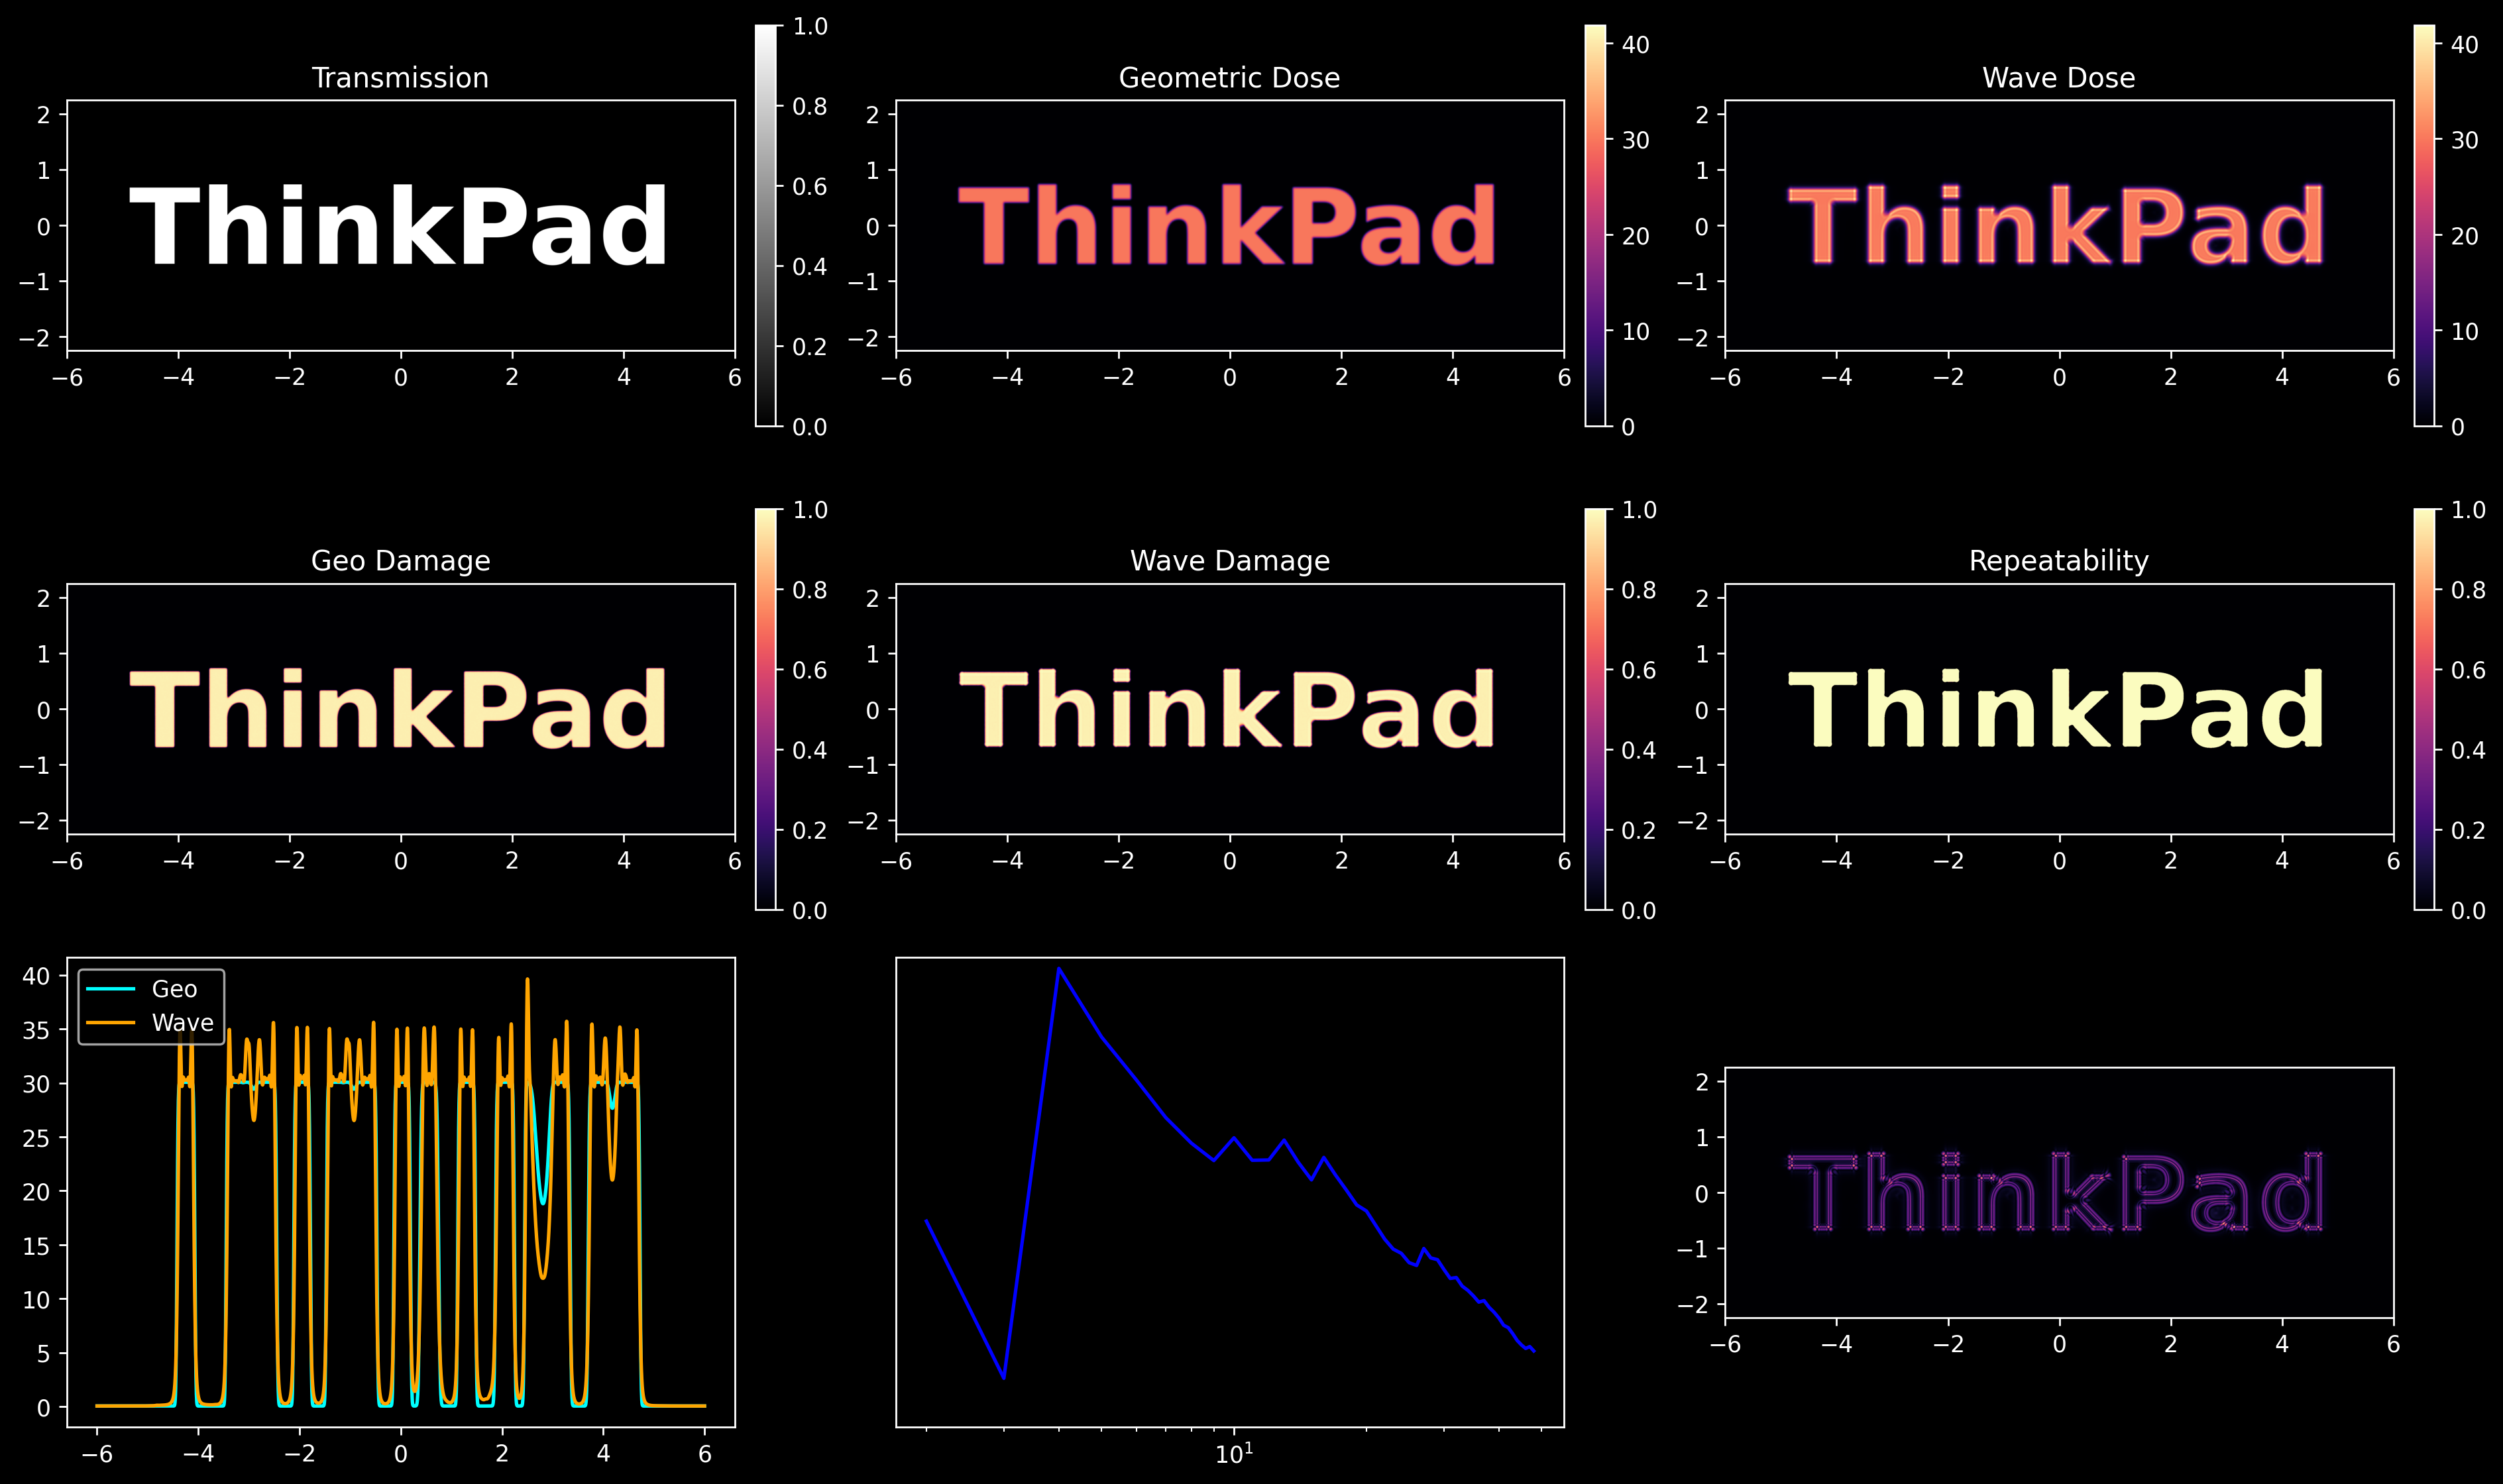

{
  "backend": "cupy",
  "pixel_nm": 3.90625,
  "elapsed_seconds": 18.259871434999923,
  "max_periodic_domain_flux_error": 4.440892098500626e-16
}


In [3]:
"""Verify CUDA FFT, kernel compilation and random sampling before simulation."""
import io
import json
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
from PIL import Image, ImageDraw, ImageFont

# - Control knobs: computation and reproducibility -
BACKEND = "auto"  # "auto", "cupy" (requires GPU), or "numpy".
SEED = 27
NX, NY = 3072, 1152
PAD_FACTOR = 2
VELOCITY_SAMPLES = 48
SHOT_REPLICATES = 24

# - Control knobs: geometry and beam -
FIELD_WIDTH_UM = 12.0
MASK_IMAGE_PATH = None
LOGO_ROTATION_DEG = 0.0
MASS_U = 4.002602
MEAN_SPEED_M_S = 1000.0
RELATIVE_SPEED_STD = 0.08
MASK_GAP_UM = 50.0
ANGLE_STD_MRAD = 0.30
SURFACE_RESPONSE_SIGMA_NM = 8.0
INCIDENT_DOSE_ATOMS_NM2 = 30.0
BACKGROUND_FRACTION = 0.002

# - Control knobs: illustrative material response and plots -
DAMAGE_D50_ATOMS_NM2 = 17.0
DAMAGE_HILL_EXPONENT = 6.0
PATTERN_DAMAGE_THRESHOLD = 0.5
REQUIRE_CROP_CAPTURE = 0.995
FIGURE_DPI = 250

plt.rcParams.update({"figure.dpi": FIGURE_DPI, "savefig.dpi": FIGURE_DPI})

def validate_settings():
    """Reject invalid settings before allocating arrays."""
    for name, value, minimum in (
        ("NX", NX, 32), ("NY", NY, 32), ("PAD_FACTOR", PAD_FACTOR, 2),
        ("VELOCITY_SAMPLES", VELOCITY_SAMPLES, 2),
        ("SHOT_REPLICATES", SHOT_REPLICATES, 2),
    ):
        if not isinstance(value, (int, np.integer)):
            raise ValueError(f"{name} must be an integer.")
        if value < minimum:
            raise ValueError(f"{name} must be at least {minimum}.")

    positive = (FIELD_WIDTH_UM, MASS_U, MEAN_SPEED_M_S, DAMAGE_D50_ATOMS_NM2, DAMAGE_HILL_EXPONENT, FIGURE_DPI)
    nonnegative = (MASK_GAP_UM, ANGLE_STD_MRAD, RELATIVE_SPEED_STD, SURFACE_RESPONSE_SIGMA_NM, INCIDENT_DOSE_ATOMS_NM2, BACKGROUND_FRACTION)

    if not all(np.isfinite(v) and v > 0 for v in positive):
        raise ValueError("Lengths, mass, speed, response constants and DPI must be positive.")
    if not all(np.isfinite(v) and v >= 0 for v in nonnegative):
        raise ValueError("Gap, spreads, dose and background must be nonnegative.")
    if not 0 < PATTERN_DAMAGE_THRESHOLD < 1:
        raise ValueError("PATTERN_DAMAGE_THRESHOLD must lie in (0, 1).")
    if not 0 < REQUIRE_CROP_CAPTURE <= 1:
        raise ValueError("REQUIRE_CROP_CAPTURE must lie in (0, 1].")

def select_backend():
    """Select a backend; permit fallback only during GPU initialization."""
    if BACKEND not in {"auto", "numpy", "cupy"}:
        raise ValueError("BACKEND must be auto, numpy, or cupy.")

    if BACKEND != "numpy":
        try:
            import cupy as cp
            if cp.cuda.runtime.getDeviceCount() < 1:
                raise RuntimeError("No CUDA device detected.")

            # Warm-up and verification
            probe = cp.arange(64, dtype=cp.float64).reshape(8, 8)
            roundtrip = cp.fft.ifft2(cp.fft.fft2(probe)).real
            if not cp.allclose(probe, roundtrip):
                raise ArithmeticError("CUDA FFT round-trip verification failed.")

            print(f"GPU verification passed. CuPy {cp.__version__}, device {cp.cuda.Device().id}.")
            return cp
        except Exception as exc:
            if BACKEND == "cupy":
                raise RuntimeError(f"GPU initialization failed: {exc}") from exc
            warnings.warn(f"CUDA unavailable; using NumPy: {exc}", stacklevel=2)

    return np

def make_mask():
    """Rasterize a typographic surrogate or fit a grayscale transmission image."""
    if MASK_IMAGE_PATH is not None:
        with Image.open(MASK_IMAGE_PATH) as source:
            img = source.convert("L")
    else:
        try:
            font_path = font_manager.findfont(font_manager.FontProperties(family="DejaVu Sans", weight="bold"))
        except:
            font_path = font_manager.findfont(font_manager.FontProperties(family="sans-serif", weight="bold"))

        scale = NX / 1024
        font = ImageFont.truetype(font_path, max(1, round(240 * scale)))
        margin = max(1, round(20 * scale))
        left, top, right, bottom = font.getbbox("ThinkPad")
        img = Image.new("L", (right - left + 2 * margin, bottom - top + 2 * margin))
        ImageDraw.Draw(img).text((margin - left, margin - top), "ThinkPad", font=font, fill=255)

    if LOGO_ROTATION_DEG:
        img = img.rotate(LOGO_ROTATION_DEG, resample=Image.Resampling.BICUBIC, expand=True)

    fit = min(NX * 0.84 / img.width, NY * 0.64 / img.height)
    img = img.resize((max(1, int(img.width * fit)), max(1, int(img.height * fit))), Image.Resampling.LANCZOS)
    canvas = Image.new("L", (NX, NY))
    canvas.paste(img, ((NX - img.width) // 2, (NY - img.height) // 2))
    mask = np.asarray(canvas, dtype=np.float64) / 255.0

    if not np.any(mask >= 0.5):
        raise ValueError("The mask must contain a target pixel with transmission >= 0.5.")
    return mask

def simulate():
    validate_settings()
    xp = select_backend()
    started = time.perf_counter()

    host_rng = np.random.default_rng(SEED)
    # Use the appropriate random state generator for the backend
    shot_rng = xp.random.RandomState(SEED) if hasattr(xp.random, 'RandomState') else np.random.RandomState(SEED)

    def host(array):
        return xp.asnumpy(array) if xp.__name__ == 'cupy' else np.asarray(array)

    mask_host = make_mask()
    mask = xp.asarray(mask_host)
    dx = FIELD_WIDTH_UM * 1e-6 / NX
    area_nm2 = (dx * 1e9) ** 2
    height, width = NY * PAD_FACTOR, NX * PAD_FACTOR
    oy, ox = (height - NY) // 2, (width - NX) // 2
    crop = (slice(oy, oy + NY), slice(ox, ox + NX))

    transmission = xp.zeros((height, width), dtype=xp.float64)
    transmission[crop] = mask
    fy = xp.fft.fftfreq(height, d=dx)[:, None]
    fx = xp.fft.fftfreq(width, d=dx)[None, :]
    f2 = fx * fx + fy * fy
    gap = MASK_GAP_UM * 1e-6
    angular_sigma = gap * ANGLE_STD_MRAD * 1e-3

    def gaussian_kernel(sigma):
        if sigma == 0:
            return xp.ones((height, width), dtype=xp.float64)
        iy, ix = xp.arange(height), xp.arange(width)
        y = xp.minimum(iy, height - iy) * dx
        x = xp.minimum(ix, width - ix) * dx
        gy = xp.exp(-0.5 * (y / sigma) ** 2)
        gx = xp.exp(-0.5 * (x / sigma) ** 2)
        kernel = (gy / gy.sum())[:, None] * (gx / gx.sum())[None, :]
        return xp.fft.fft2(kernel)

    angular_transfer = gaussian_kernel(angular_sigma)
    surface_transfer = gaussian_kernel(SURFACE_RESPONSE_SIGMA_NM * 1e-9)

    def blur(array, kernel):
        output = xp.fft.ifft2(xp.fft.fft2(array) * kernel).real
        return xp.maximum(output, 0.0)

    spectrum = xp.fft.fft2(xp.sqrt(transmission))
    geometric_full = blur(transmission, angular_transfer)
    mean = xp.zeros_like(transmission)
    dose_mean = xp.zeros((NY, NX), dtype=xp.float64)
    dose_m2 = xp.zeros_like(dose_mean)

    log_sigma = np.sqrt(np.log1p(RELATIVE_SPEED_STD ** 2))
    speeds = host_rng.lognormal(np.log(MEAN_SPEED_M_S) - log_sigma**2 / 2, log_sigma, VELOCITY_SAMPLES)
    wavelengths = 6.62607015e-34 / (MASS_U * 1.66053906660e-27 * speeds)

    flux_errors, history = [], []
    source_sum = float(transmission.sum())

    for index, wavelength in enumerate(wavelengths, start=1):
        transfer = xp.exp(-1j * np.pi * wavelength * gap * f2)
        field = xp.fft.ifft2(spectrum * transfer)
        intensity = xp.abs(field) ** 2
        flux_errors.append(abs(float(intensity.sum()) / source_sum - 1))
        intensity = blur(intensity, angular_transfer)
        mean += (intensity - mean) / index

        mode_dose = INCIDENT_DOSE_ATOMS_NM2 * blur(intensity, surface_transfer)[crop]
        delta = mode_dose - dose_mean
        dose_mean += delta / index
        dose_m2 += delta * (mode_dose - dose_mean)
        if index > 1:
            se2 = xp.maximum(dose_m2, 0.0) / ((index - 1) * index)
            history.append((index, float(xp.sqrt(xp.mean(se2)))))

    mc_se = xp.sqrt(xp.maximum(dose_m2, 0.0) / ((VELOCITY_SAMPLES - 1) * VELOCITY_SAMPLES))

    def damage(dose):
        safe_ratio = xp.maximum(dose / DAMAGE_D50_ATOMS_NM2, xp.finfo(xp.float64).tiny)
        log_odds = DAMAGE_HILL_EXPONENT * xp.log(safe_ratio)
        response = xp.exp(-xp.logaddexp(0.0, -log_odds))
        return xp.where(dose > 0, response, 0.0)

    results = []
    target = mask >= 0.5
    for label, intensity in (("Geometric atom beam", geometric_full), ("Matter-wave beam", mean)):
        arrival = INCIDENT_DOSE_ATOMS_NM2 * (intensity + BACKGROUND_FRACTION)
        mean_dose = blur(arrival, surface_transfer)
        probability = xp.zeros((NY, NX), dtype=xp.float64)
        overlaps = []
        for rep in range(SHOT_REPLICATES):
            counts = shot_rng.poisson(arrival * area_nm2)
            realized_dose = blur(counts / area_nm2, surface_transfer)[crop]
            response = damage(realized_dose)
            pattern = response >= PATTERN_DAMAGE_THRESHOLD
            probability += pattern / SHOT_REPLICATES
            intersection = int(xp.count_nonzero(pattern & target))
            union = int(xp.count_nonzero(pattern | target))
            overlaps.append(intersection / union if union else 1.0)
            if rep == 0:
                sample_dose = host(realized_dose.copy())
                sample_response = host(response.copy())

        results.append({
            "label": label, "dose": host(mean_dose[crop]),
            "sample_dose": sample_dose, "response": sample_response,
            "probability": host(probability), "iou": overlaps,
        })

    if xp.__name__ == 'cupy':
        xp.cuda.get_current_stream().synchronize()

    diagnostics = {
        "backend": xp.__name__, "pixel_nm": dx * 1e9,
        "elapsed_seconds": time.perf_counter() - started,
        "max_periodic_domain_flux_error": max(flux_errors),
    }

    # RELAXED TOLERANCE: 1e-9 is too strict for large array sums
    if max(flux_errors) >= 1e-6:
        raise ArithmeticError(f"Propagation failed flux conservation: {max(flux_errors):.2e}")

    return mask_host, results, host(mc_se), np.asarray(history), diagnostics

def visualize(mask, results, mc_se, history, diagnostics):
    half_height = FIELD_WIDTH_UM * NY / NX / 2
    extent = [-FIELD_WIDTH_UM / 2, FIELD_WIDTH_UM / 2, -half_height, half_height]
    dose_max = max(float(r["dose"].max()) for r in results) or 1.0

    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(3, 3, figsize=(15, 9), layout="constrained")
        panels = [
            (mask, "Transmission", "gray", 1),
            (results[0]["dose"], "Geometric Dose", "magma", dose_max),
            (results[1]["dose"], "Wave Dose", "magma", dose_max),
            (results[0]["response"], "Geo Damage", "magma", 1),
            (results[1]["response"], "Wave Damage", "magma", 1),
            (results[1]["probability"], "Repeatability", "magma", 1),
        ]
        for ax, (data, title, cmap, vmax) in zip(axes.flat, panels):
            im = ax.imshow(data, origin="upper", extent=extent, cmap=cmap, vmin=0, vmax=vmax)
            ax.set(title=title)
            fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

        row = int(np.argmax(mask.sum(axis=1)))
        x = extent[0] + (np.arange(NX) + 0.5) * FIELD_WIDTH_UM / NX
        axes[2, 0].plot(x, results[0]["dose"][row], color="cyan", label="Geo")
        axes[2, 0].plot(x, results[1]["dose"][row], color="orange", label="Wave")
        axes[2, 0].legend()

        axes[2, 1].plot(history[:, 0], history[:, 1], color="#0000ff")
        axes[2, 1].set_xscale("log")
        axes[2, 1].set_yscale("symlog", linthresh=1e-12)

        axes[2, 2].imshow(mc_se, extent=extent, origin="upper", cmap="magma")

        plt.show()
        plt.close(fig)

    print(json.dumps(diagnostics, indent=2))
    return True

if __name__ == "__main__":
    mask, results, mc_se, history, diagnostics = simulate()
    visualize(mask, results, mc_se, history, diagnostics)